#Installierung von pandas und aufladung von Dataset

In [137]:
import pandas as pd 

daten = pd.read_csv("immo_data.csv", low_memory=False)

aber wir wollen nur die Stadt von München beobachten

In [138]:
daten_münchen = daten[daten["regio2"] == "München"]


wir zeigen die Größe des Dataset und die 5 erste zeile

In [139]:
print(f"anzahl der Anzeigen in München sind:", {daten_münchen.shape[0]})
display(daten_münchen)

anzahl der Anzeigen in München sind: {4383}


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
23,Bayern,180.0,central_heating,ONE_YEAR_FREE,NaN,False,False,18,4.47,10.0,...,München,Altstadt,Die Wohnung (OHNE Balkon !!) liegt im 4. OG (O...,- Eichenparkettboden im Wohn-EZ u. im Schlafzi...,NaN,NO_INFORMATION,NaN,NaN,NaN,Oct19
28,Bayern,0.0,NaN,ONE_YEAR_FREE,NaN,False,True,25,7.53,40.0,...,München,Schwabing_West,"Highlights:\n\n * alle Wände der Wohnräume, Kü...",Waschmaschine in der Wohnung\nFlachbildfernseh...,NaN,NaN,NaN,NaN,NaN,May19
32,Bayern,0.0,NaN,ONE_YEAR_FREE,NaN,False,True,29,6.08,40.0,...,München,Milbertshofen,Bitte beachten Sie: Die Wohnung ist komplett m...,Waschmaschine in der Wohnung\nFlachbildfernseh...,NaN,NaN,NaN,NaN,NaN,Feb20
118,Bayern,NaN,NaN,NaN,NaN,True,True,14,7.32,NaN,...,München,Schwabing,Möbliertes Wohnen auf Zeit:\nModernes Apartmen...,Bettwäsche\nCouch\nDusche\nEinbauküche\nFranzö...,NaN,C,NaN,NaN,NaN,May19
161,Bayern,290.0,district_heating,ONE_YEAR_FREE,NaN,False,True,16,5.72,10.0,...,München,Ludwigsvorstadt_Isarvorstadt,"Das Mehrfamilienhaus ""COR 4"" (60er Jahre Kult)...",Eichenparkett m. weißen Sockelleisten\nFußbode...,NaN,NO_INFORMATION,2019.0,NaN,NaN,Oct19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268688,Bayern,320.0,oil_heating,ONE_YEAR_FREE,NaN,False,True,24,4.88,10.0,...,München,Obermenzing,"Die traumhaft gelegene, 2019/2020 komplett san...","Echtholz-Eichendielenparkett: Wohnzimmer, Schl...",NaN,D,2020.0,NaN,NaN,Feb20
268712,Bayern,165.0,district_heating,ONE_YEAR_FREE,NaN,False,True,11,5.88,40.0,...,München,Ramersdorf,Gepflegte Wohnanlage mit Spielplätzen und groß...,* die Wohnräume sind mit neuem Parkett ausgest...,160.0,NaN,2019.0,NaN,NaN,Oct19
268752,Bayern,0.0,central_heating,ONE_YEAR_FREE,10.0,False,True,32,7.44,2.4,...,München,Milbertshofen,"Dieses komplett sanierte, möblierte und voll a...",Große helle Fliesen in Küche und Bad (weiss u....,NaN,NaN,2019.0,NaN,NaN,May19
268818,Bayern,180.0,central_heating,ONE_YEAR_FREE,NaN,False,True,9,6.96,40.0,...,München,Bogenhausen,Die frisch sanierte Wohnung begrüßt Sie mit ei...,- Kellerabteil\n- Bad mit Badewanne und WC\n- ...,175.0,NaN,2019.0,NaN,NaN,May19


versuchen wir wichtige Spalte zu suchen


In [140]:
nötige_spalte = [
    "baseRent",     # unsere Target, was wir vorhersagen wollen
    "livingSpace",  # Fläche in m²
    "noRooms",      # Anzahl der Zimmern
    "condition",    # Zustand/Status der Wohnung
    "yearConstructed",  # Baujahr
    "balcony",      # gibt es balkon oder nicht
    "regio3",       # Stadtviertel
    "lift",         # Ascenceur
    "hasKitchen"
]


daten_münchen_bereinigt = daten_münchen[nötige_spalte].copy()

Danach müssen wir die Nan-Spalte gucken und sie zählen

In [141]:
display(daten_münchen_bereinigt.isnull().sum())


baseRent              0
livingSpace           0
noRooms               0
condition          1206
yearConstructed     751
balcony               0
regio3                0
lift                  0
hasKitchen            0
dtype: int64

Aktuell will ich gerne die Nan löschen

In [142]:
daten_münchen_bereinigt = daten_münchen_bereinigt.dropna()


EDA: Explorative Daten analyse

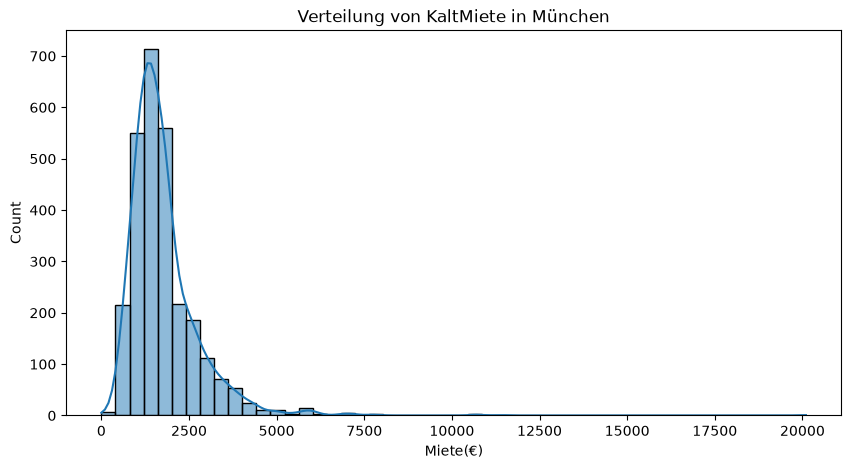

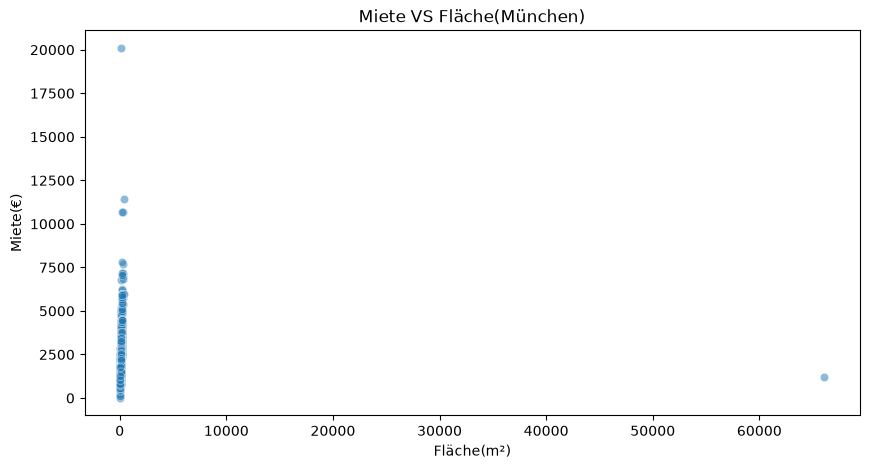

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns



# Graphik1 : Verteilung von Miete in München

plt.figure(figsize=(10,5))
sns.histplot(daten_münchen_bereinigt["baseRent"], bins=50, kde=True)
plt.title("Verteilung von KaltMiete in München")
plt.xlabel("Miete(€)")
plt.show()

# Graphik1 : Verteilung von Miete in München
plt.figure(figsize=(10,5))
sns.scatterplot(data=daten_münchen_bereinigt, x="livingSpace", y="baseRent", alpha=0.5)
plt.title("Miete VS Fläche(München)")
plt.xlabel("Fläche(m²)")
plt.ylabel("Miete(€)")
plt.show()

Achso ich habe meine Grafike analysieren und ich habe gemerkt. dass es einige Ausreißer gibt. Die idee ist doch die verhältnis Miete/Fläche realistisch zu machen

Dafür habe ich eine Intervall ausgewählt, die Kaltmiete müssen zwischen 300 und 5000 bleiben aber Fläche der Häuser zwischen 15 und 300

In [144]:
daten_münchen_bereinigt = daten_münchen_bereinigt[
    (daten_münchen_bereinigt['baseRent'] >= 300) & (daten_münchen_bereinigt['baseRent'] <= 5000) &
    (daten_münchen_bereinigt['livingSpace'] >= 15) & (daten_münchen_bereinigt['livingSpace'] <= 300)
]

suchen wir, wie viele Daten es noch gibt?

In [145]:
print(f"Anzahl der Anzeige nach der bereinigung: {daten_münchen_bereinigt.shape[0]}")

Anzahl der Anzeige nach der bereinigung: 2721


Natürlich ein neue Graphik soll ich erstellen:

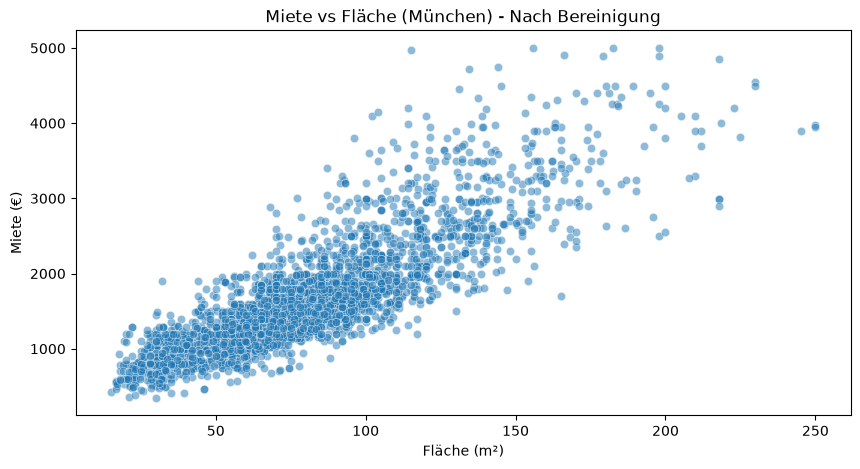

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.scatterplot(data=daten_münchen_bereinigt, x='livingSpace', y='baseRent', alpha=0.5)
plt.title("Miete vs Fläche (München) - Nach Bereinigung")
plt.xlabel("Fläche (m²)")
plt.ylabel("Miete (€)")
plt.show()

Encodierung der Strings-Variable "Conditions" und "regio3"

In [147]:
daten_münchen_für_ML = pd.get_dummies(daten_münchen_bereinigt, columns=['condition', 'regio3'], drop_first=True)

Joo!!! wir haben die Spalte "Balcony" vergessen , diese Spalte enthält die Strings und wir können nicht damit arbeiten, wir brauchen zahlen deswegen werde ich Balcony in Booleen (0,1) konvertieren. 


In [148]:
if 'hasBalcony' in daten_münchen_für_ML.columns:
    daten_münchen_für_ML['hasBalcony'] = daten_münchen_für_ML['hasBalcony'].astype(int)

jetzt was ist unsere X? , was ist unsere y?

In [149]:
X = daten_münchen_für_ML.drop('baseRent', axis=1) #alles außer kaltmiete
y = daten_münchen_für_ML['baseRent']

Train/Test split (80% fürs Training und nur 20% für Test)

In [150]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42) 

Standardisierung der Variablen

In [151]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#wir fitten jetzt nur die Trainingsdaten:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [152]:
print(f"Dimensionen von X_train : {X_train_scaled.shape}")
print(f"Dimensionen von X_test : {X_test_scaled.shape}")
print("Die daten sind für Machine Learning bereit !")

Dimensionen von X_train : (2176, 55)
Dimensionen von X_test : (545, 55)
Die daten sind für Machine Learning bereit !


Aufrufe der Funktionen, Bibliothek, und Modelle, die wir brauchen werden:

In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

1-Basislinie : LinearRegression

In [154]:
modell_lr = LinearRegression()
modell_lr.fit(X_train_scaled, y_train)

y_predict_von_lr = modell_lr.predict(X_test_scaled)

Berechnung der Fehler des Modells (lineare Regression)

In [155]:
rmse_lr = root_mean_squared_error(y_test, y_predict_von_lr)
print(f"durchschnittle Fehler des Modells ist: {rmse_lr:.2f} €")

durchschnittle Fehler des Modells ist: 290.09 €


2- Forgeschrittenes Modell : Randomforest

In [156]:
modell_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modell_rf.fit(X_train_scaled, y_train)
y_predict_von_rf = modell_rf.predict(X_test_scaled)


#gleich wie bei der linearen Regression, fehler Berechnen:
rmse_rf = root_mean_squared_error(y_test, y_predict_von_rf)
print(f"durchschnittle Fehler des Modells ist: {rmse_rf:.2f} €")


durchschnittle Fehler des Modells ist: 308.25 €


3- Gradient Boosting

In [157]:
from sklearn.ensemble import GradientBoostingRegressor

# wir bewahren 100 estimators um genau gleich mit Random Forest zu vergleichen

modell_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
modell_gb.fit(X_train_scaled, y_train)
y_pred_gb = modell_gb.predict(X_test_scaled)

rmse_gb = root_mean_squared_error(y_test, y_pred_gb)
print(f"durchschnittle Fehler des Modells ist : {rmse_gb:.2f} €")

durchschnittle Fehler des Modells ist : 286.20 €
